# 12 - Check Wavelength Grid Uniformity

This notebook inspects whether the wavelength grids in the CARMENES VIS-A data are uniform (equal spacing) and consistent across observations for each order.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

with open("../../aumicAE/data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = ["../../aumicAE/" + line.strip().lstrip("../") for line in f if line.strip()]

order = 25  # try 25, 46, 47, etc.

def load_wave(file, order):
    with fits.open(file) as hdul:
        return hdul["WAVE"].data[order]

wave_grids = np.array([load_wave(f, order) for f in vis_a_files])

Check delta-lambda (spacing):

In [ ]:
for i in range(5):
    delta_lambda = np.diff(wave_grids[i])
    print(f"Spectrum {i}: mean Δλ = {np.mean(delta_lambda):.6f}, std = {np.std(delta_lambda):.2e}")

Spectrum 0: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 1: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 2: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 3: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 4: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 5: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 6: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 7: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 8: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 9: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 10: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 11: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 12: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 13: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 14: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 15: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 16: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 17: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 18: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 19: mean Δλ = 0.035158, std = 5.27e-03
Spectrum 20: mean Δλ = 0.035158, std = 5.27e-03
Sp

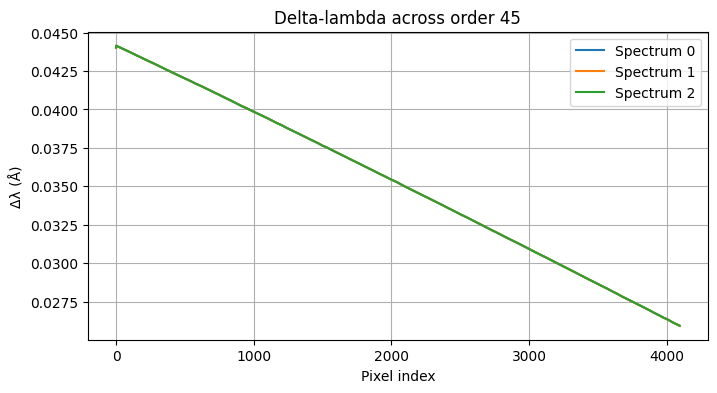

In [7]:
plt.figure(figsize=(8, 4))
for i in range(3):
    delta_lambda = np.diff(wave_grids[i])
    plt.plot(delta_lambda, label=f"Spectrum {i}")
plt.xlabel("Pixel index")
plt.ylabel("Δλ (Å)")
plt.title(f"Delta-lambda across order {order}")
plt.legend()
plt.grid()
plt.show()

Check for all relevant orders:

In [9]:
orders = range(17, 39)
tol = 1e-6  # tolerance for considering mean Δλ equal

for order in orders:
    deltas = []
    for path in vis_a_files:
        with fits.open(path) as hdul:
            wave = hdul["WAVE"].data[order]
            delta_lambda = np.diff(wave)
            deltas.append(np.mean(delta_lambda))
    
    deltas = np.array(deltas)
    if np.allclose(deltas, deltas[0], rtol=0, atol=tol):
        print(f"Order {order}: mean Δλ = {deltas[0]:.6f} Å (same across all spectra)")
    else:
        print(f"Order {order}: Δλ varies across spectra")
        for i, d in enumerate(deltas):
            print(f"  Spectrum {i:02d}: mean Δλ = {d:.6f} Å")

Order 17: mean Δλ = 0.025536 Å (same across all spectra)
Order 18: mean Δλ = 0.025787 Å (same across all spectra)
Order 19: mean Δλ = 0.026043 Å (same across all spectra)
Order 20: mean Δλ = 0.026303 Å (same across all spectra)
Order 21: mean Δλ = 0.026570 Å (same across all spectra)
Order 22: mean Δλ = 0.026842 Å (same across all spectra)
Order 23: mean Δλ = 0.027120 Å (same across all spectra)
Order 24: mean Δλ = 0.027403 Å (same across all spectra)
Order 25: mean Δλ = 0.027693 Å (same across all spectra)
Order 26: mean Δλ = 0.027989 Å (same across all spectra)
Order 27: mean Δλ = 0.028292 Å (same across all spectra)
Order 28: mean Δλ = 0.028602 Å (same across all spectra)
Order 29: mean Δλ = 0.028918 Å (same across all spectra)
Order 30: mean Δλ = 0.029242 Å (same across all spectra)
Order 31: mean Δλ = 0.029573 Å (same across all spectra)
Order 32: mean Δλ = 0.029912 Å (same across all spectra)
Order 33: mean Δλ = 0.030259 Å (same across all spectra)
Order 34: mean Δλ = 0.030614 Å 

All orders already have uniformly spaced wavelength grids (constant Δλ per order)

Within each order, the Δλ is identical across all 95 spectra

But Δλ varies between orders, which is expected due to instrument design (bluer orders are more compressed)

**This means:**

- we  don’t need to rebuild grids from scratch

- we can take one reference wavelength grid per order, e.g. from wave_data[order]

- then we can:

    1. Shift each spectrum by its RV using doppler_shift
    2. Interpolate back to the reference grid (which has fixed Δλ)
    3. Trim the edges to the valid shared wavelength range across all spectra